In [4]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline


In [5]:
img=cv2.imread('./test_images/sharapova1.jpg')
img.shape

(555, 700, 3)

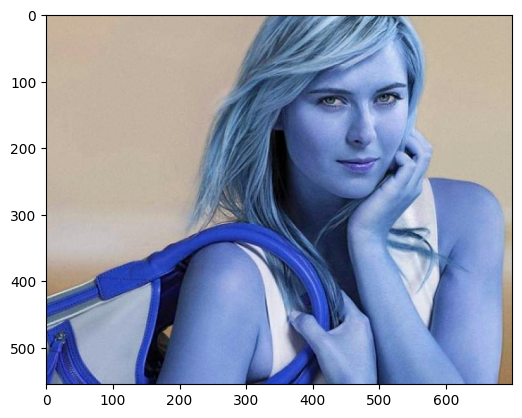

In [6]:
plt.imshow(img)

In [7]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

In [8]:
gray

array([[175, 175, 175, ..., 176, 175, 174],
       [175, 175, 175, ..., 177, 175, 174],
       [175, 175, 175, ..., 177, 176, 174],
       ...,
       [ 84,  87,  88, ..., 113, 113, 113],
       [ 88,  89,  90, ..., 113, 113, 113],
       [ 93,  91,  91, ..., 112, 112, 112]], shape=(555, 700), dtype=uint8)

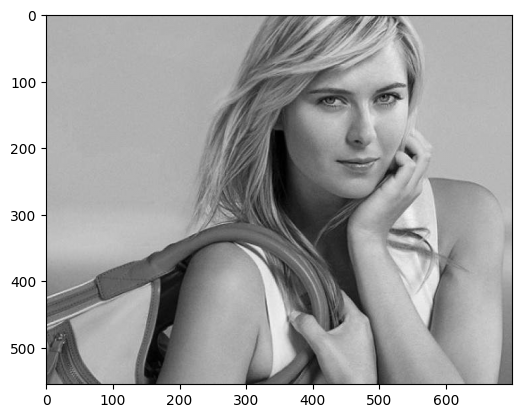

In [9]:
plt.imshow(gray,cmap='gray')

In [10]:
face_cascade=cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade=cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')
faces=face_cascade.detectMultiScale(gray,1.3,5)
faces

array([[352,  38, 233, 233]], dtype=int32)

In [11]:
(x,y,w,h)=faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

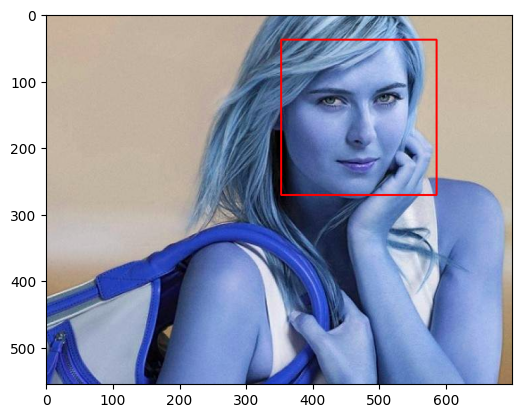

In [12]:
face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

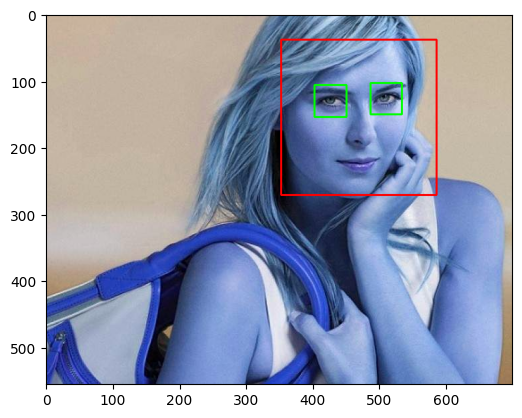

In [13]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

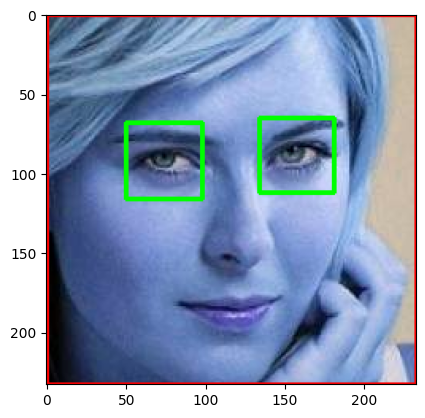

In [14]:
%matplotlib inline
plt.imshow(roi_color,cmap='gray')

In [15]:
def get_cropped_images_if_2_eyes(img_path):
    img = cv2.imread(img_path)
    
    if img is None:
        return []
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    cropped_faces = []
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(faces) == 1 and len(eyes) >= 2:
            cropped_faces.append(roi_color) 
    return cropped_faces

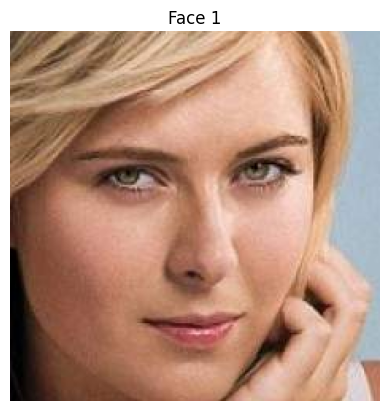

In [16]:
cropped_faces = get_cropped_images_if_2_eyes('./test_images/sharapova1.jpg')

for i, face in enumerate(cropped_faces):
    plt.figure()
    plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    plt.title(f"Face {i+1}")
    plt.axis('off')

plt.show()

In [22]:
cropped_faces2 = get_cropped_images_if_2_eyes('./test_images/sharapova2.JPG')

for i, face in enumerate(cropped_faces2):
    plt.figure()
    plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    plt.title(f"Face {i+1}")
    plt.axis('off')

plt.show()

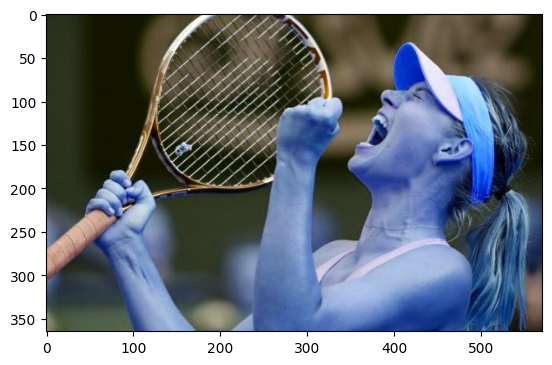

In [23]:
orign_img=cv2.imread('./test_images/sharapova2.JPG')
plt.imshow(orign_img)

In [99]:
path_to_data="./dataset/"
path_to_cr_data="./dataset/cropped/"

In [100]:
import os
img_dirs=[]
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
       
img_dirs

['./dataset/Angelina_Jolie',
 './dataset/Brad_Pitt',
 './dataset/cropped',
 './dataset/Jennifer_Lawrence',
 './dataset/Johnny_Depp',
 './dataset/lionel_messi',
 './dataset/maria_sharapova',
 './dataset/Natalie_Portman',
 './dataset/roger_federer',
 './dataset/Scarlett_Johansson',
 './dataset/serena_williams',
 './dataset/virat_kohli']

In [101]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [102]:
cropped_img_dirs = []
celeb_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celeb_name = img_dir.split('/')[-1]
    celeb_file_names_dict[celeb_name]=[]

    for entry in os.scandir(img_dir):

        cropped_faces = get_cropped_images_if_2_eyes(entry.path)

        if len(cropped_faces) == 0:
            continue

        cropped_folder = path_to_cr_data + celeb_name

        if not os.path.exists(cropped_folder):
            os.makedirs(cropped_folder)
            cropped_img_dirs.append(cropped_folder)
            print("Generating cropped images in folder:", cropped_folder)

        for roi_color in cropped_faces:
            cropped_file_name = celeb_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name

            cv2.imwrite(cropped_file_path, roi_color)  
            celeb_file_names_dict[celeb_name].append(cropped_file_path)
            count += 1

Generating cropped images in folder: ./dataset/cropped/Angelina_Jolie
Generating cropped images in folder: ./dataset/cropped/Brad_Pitt
Generating cropped images in folder: ./dataset/cropped/Jennifer_Lawrence
Generating cropped images in folder: ./dataset/cropped/Johnny_Depp
Generating cropped images in folder: ./dataset/cropped/lionel_messi
Generating cropped images in folder: ./dataset/cropped/maria_sharapova
Generating cropped images in folder: ./dataset/cropped/Natalie_Portman
Generating cropped images in folder: ./dataset/cropped/roger_federer
Generating cropped images in folder: ./dataset/cropped/Scarlett_Johansson
Generating cropped images in folder: ./dataset/cropped/serena_williams
Generating cropped images in folder: ./dataset/cropped/virat_kohli


In [126]:
celeb_file_names_dict = {}
for img_dir in cropped_img_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celeb_file_names_dict[celebrity_name] = file_list
celeb_file_names_dict

{'Angelina_Jolie': ['./dataset/cropped/Angelina_Jolie\\Angelina_Jolie1.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie10.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie11.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie12.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie13.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie14.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie15.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie16.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie17.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie18.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie19.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie2.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie20.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie21.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie22.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie23.png',
  './dataset/cropped/Ang

In [116]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

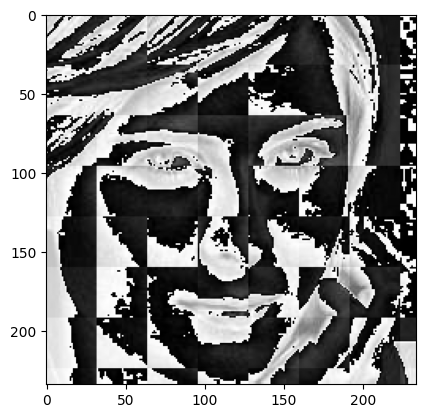

In [24]:
for face in cropped_faces:
    im_har = w2d(img=face, mode='db1', level=5)
    plt.imshow(im_har, cmap='gray')
    plt.show()

In [127]:
celeb_file_names_dict

{'Angelina_Jolie': ['./dataset/cropped/Angelina_Jolie\\Angelina_Jolie1.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie10.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie11.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie12.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie13.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie14.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie15.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie16.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie17.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie18.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie19.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie2.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie20.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie21.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie22.png',
  './dataset/cropped/Angelina_Jolie\\Angelina_Jolie23.png',
  './dataset/cropped/Ang

In [128]:
class_dict={}
count=0
for celebrity_name in celeb_file_names_dict.keys():
    class_dict[celebrity_name]=count
    count=count+1
class_dict

{'Angelina_Jolie': 0,
 'Brad_Pitt': 1,
 'Jennifer_Lawrence': 2,
 'Johnny_Depp': 3,
 'lionel_messi': 4,
 'maria_sharapova': 5,
 'Natalie_Portman': 6,
 'roger_federer': 7,
 'Scarlett_Johansson': 8,
 'serena_williams': 9,
 'virat_kohli': 10}

In [147]:
x = []
y = []

IMG_SIZE = 48

for celebrity_name, training_files in celeb_file_names_dict.items():
    for training_img in training_files:
        img = cv2.imread(training_img)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        scaled_raw_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img_har = w2d(img=scaled_raw_img, mode='db1', level=5)
        scaled_img_har = cv2.resize(img_har, (IMG_SIZE, IMG_SIZE))

        combined_img = np.concatenate((
            scaled_raw_img.reshape(IMG_SIZE * IMG_SIZE * 3,),
            scaled_img_har.reshape(IMG_SIZE * IMG_SIZE,)
        ))

        x.append(combined_img)
        y.append(class_dict[celebrity_name])

X = np.array(x).astype(float)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (652, 9216)
y shape: (652,)


In [148]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [149]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
pipe =Pipeline([('scaler',StandardScaler()),('svm',SVC(C=10,kernel='linear',gamma='auto'))])
pipe.fit(x_train,y_train)
pipe.score(x_test,y_test)

0.8015267175572519

In [150]:
print(classification_report(y_test,pipe.predict(x_test)))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        20
           1       0.54      0.78      0.64         9
           2       0.70      0.89      0.78        18
           3       0.89      0.80      0.84        10
           4       1.00      0.86      0.92         7
           5       0.50      0.20      0.29         5
           6       0.79      0.79      0.79        14
           7       1.00      0.50      0.67         2
           8       0.92      0.87      0.89        38
           9       0.60      1.00      0.75         3
          10       0.83      1.00      0.91         5

    accuracy                           0.80       131
   macro avg       0.78      0.76      0.75       131
weighted avg       0.82      0.80      0.80       131



In [154]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [167]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',kernel='linear'),
        'params' : {
            'svc__C': [1,10,20],
            'svc__probability': [True,False]
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [50,100],
            'randomforestclassifier__max_depth':[20,50,100]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(max_iter=100),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [168]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(x_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.660220,"{'svc__C': 1, 'svc__probability': True}"
1,random_forest,0.525934,"{'randomforestclassifier__max_depth': 100, 'ra..."
2,logistic_regression,0.690952,{'logisticregression__C': 1}


In [172]:
best_estimators['svm'].score(x_test,y_test)

0.8015267175572519

In [174]:
best_estimators['random_forest'].score(x_test,y_test)

0.6641221374045801

In [173]:
best_estimators['logistic_regression'].score(x_test,y_test)

0.7709923664122137

In [176]:
best_clf=best_estimators['logistic_regression']

In [177]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,best_clf.predict(x_test))
cm

array([[14,  0,  1,  1,  0,  0,  4,  0,  0,  0,  0],
       [ 0,  6,  1,  0,  0,  0,  0,  0,  2,  0,  0],
       [ 1,  0, 14,  0,  0,  0,  0,  0,  1,  2,  0],
       [ 0,  1,  0,  8,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  6,  0,  0,  0,  0,  0,  1],
       [ 0,  1,  2,  1,  0,  1,  0,  0,  0,  0,  0],
       [ 1,  0,  1,  0,  0,  1, 10,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  1],
       [ 1,  0,  2,  0,  0,  0,  1,  0, 34,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5]])

Text(95.72222222222221, 0.5, 'Truth')

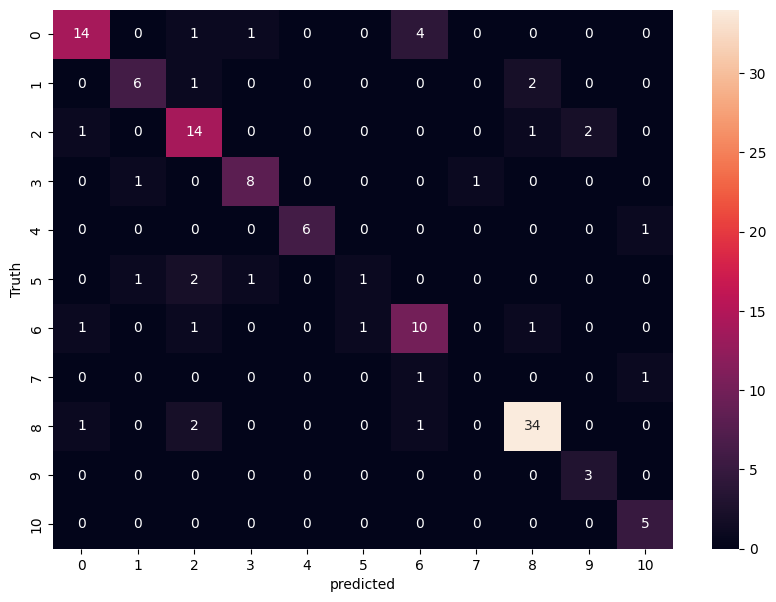

In [178]:
import seaborn as sb
plt.figure(figsize=(10,7))
sb.heatmap(cm,annot=True)
plt.xlabel('predicted')
plt.ylabel('Truth')

In [179]:
class_dict

{'Angelina_Jolie': 0,
 'Brad_Pitt': 1,
 'Jennifer_Lawrence': 2,
 'Johnny_Depp': 3,
 'lionel_messi': 4,
 'maria_sharapova': 5,
 'Natalie_Portman': 6,
 'roger_federer': 7,
 'Scarlett_Johansson': 8,
 'serena_williams': 9,
 'virat_kohli': 10}

In [180]:
%pip install joblib
import joblib
joblib.dump(best_clf,'saved_model.pkl')

Note: you may need to restart the kernel to use updated packages.


['saved_model.pkl']

In [181]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))